This playground contains all our experiments with the MSE gradient descent model.

In [88]:
from implementations import *
import numpy as np
from helpers import *

debug = False  # turn this on to see verbose logs
MAX_OPS = pow(10, 5) # how much compute this model should have at disposal

# x_train, x_test, y_train, train_ids, test_ids = load_csv_data("data/dataset")
# loading is too slow, I use this for testing -M
path_to_dataset = "data/dataset"
x_train, x_test, y_train, train_ids, test_ids = load_csv_data(
    path_to_dataset, max_rows=500, max_features=None, NaNstrat="fill"
)
tx, mask = preprocess(x_train)
# remove 0-variance in test data too
x_test = x_test[:, mask]
if debug : print("tx.shape", tx.shape)
if debug : print("y_train.shape", y_train.shape)

Split the data for cross validation.

In [89]:
tx_train_split, tx_test_split, y_train_split, y_test_split = split_data(tx, y_train) # unused for now, use this for cross-validation

Set model hyper-parameters.

In [135]:
w0 = np.zeros(tx.shape[1])
max_iters = 100
delta = MAX_OPS // max_iters // 5
print("mesh resolution =", delta)
# gammas = np.geomspace(0.1, 100, num = delta)
gammas = np.linspace(start = 0.0901, stop = 0.1015, num = delta)

xs = []
losses = []

for gamma in gammas:
    w, loss = mean_squared_error_gd(y_train_split, tx_train_split, w0, max_iters, gamma)
    # print(gamma, "->", loss)
    xs.append(gamma)
    losses.append(loss)

# print(losses)
opt_gamma = xs[np.argmin(losses)]
print(np.argmin(losses))
print("opt gamma =", opt_gamma)

mesh resolution = 200
188
opt gamma = 0.10086984924623116


Training is done. Onto testing!

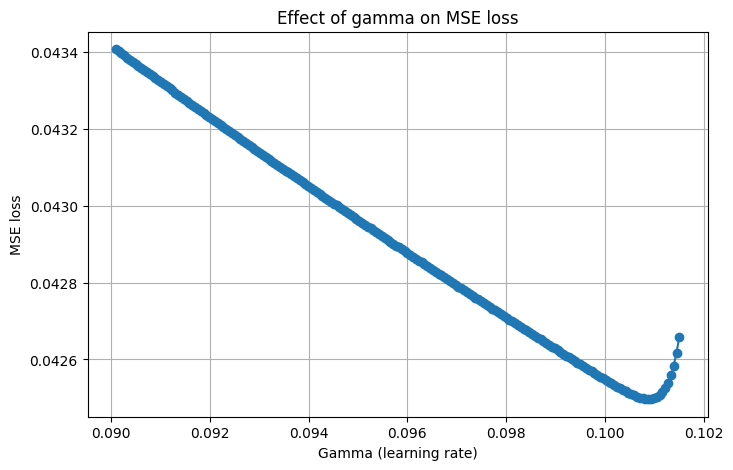

In [124]:
# display

plt.figure(figsize=(8,5))
plt.plot(gammas, losses, marker='o')
plt.xlabel("Gamma (learning rate)")
plt.ylabel("MSE loss")
plt.title("Effect of gamma on MSE loss")
plt.grid(True)

plt.savefig("gamma_vs_loss.png", dpi=300, bbox_inches='tight')
plt.show()

In [139]:
# print optimal solution
w, _ = mean_squared_error_gd(y_test_split, tx_test_split, w0, max_iters, opt_gamma) 
y_pred = tx_test_split @ w
print(np.sign(y_pred))

[-1.  1.  1. -1. -1. -1. -1. -1. -1.  1. -1. -1. -1. -1.  1. -1. -1. -1.
 -1. -1. -1. -1.  1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1. -1. -1.
 -1.  1. -1.  1.  1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.
 -1. -1. -1.  1. -1.  1.  1. -1.  1. -1. -1. -1. -1. -1. -1.  1. -1.  1.
 -1. -1. -1. -1. -1. -1. -1. -1. -1. -1. -1.  1. -1. -1.  1. -1. -1. -1.
 -1. -1. -1. -1. -1. -1.  1. -1.  1. -1.]
